In [4]:
import sys
from pathlib import Path

# Jupyter cwd가 src/ 등일 때도 동작하도록, common/state.py가 있는 디렉터리를 루트로 잡음
def _project_root() -> Path:
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "common" / "state.py").is_file():
            return p
    return here


_root = _project_root()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))


In [5]:
from __future__ import annotations

from typing import Literal

from langgraph.graph import END, START, StateGraph

from common.state import AgentState


GraphRoute = Literal[
    "supervisor",
    "research",
    "analytic",
    "calculator",
    "final_answer",
    "end",
]


def supervisor(state: AgentState) -> AgentState:
    from src.agents.supervisor import supervisor as supervisor_agent

    return supervisor_agent(state)


def research(state: AgentState) -> AgentState:
    from src.agents.research_agent import research_agent

    next_state = {
        **state,
        "character_name": state.get("character_name", ""),
        "world_name": state.get("world_name", ""),
    }
    return research_agent(next_state)


def analytic(state: AgentState) -> AgentState:
    from src.agents.analytics import analytics_agent

    return analytics_agent(state=state)


def calculator(state: AgentState) -> AgentState:
    from src.agents.calculator import calculator_agent

    return calculator_agent(state=state)


def final_answer(state: AgentState) -> AgentState:
    from src.agents.final_answer import run_final_answer_agent

    next_state = {
        **state,
        "context": state.get("context", ""),
        "recommended_actions": state.get("recommended_actions", []),
    }
    return run_final_answer_agent(next_state)


def evaluation(state: AgentState) -> AgentState:
    final_answer_text = str(state.get("final_answer") or "").strip()
    has_answer = bool(final_answer_text)
    is_pass = has_answer
    retry_count = int(state.get("retry_count", 0))

    tool_results = dict(state.get("tool_results", {}))
    tool_results["evaluation"] = {
        "is_pass": is_pass,
        "has_answer": has_answer,
        "retry_target": "supervisor" if not is_pass else "FINISH",
    }

    if is_pass:
        return {
            **state,
            "tool_results": tool_results,
            "validation_passed": True,
            "is_complete": True,
            "retry_target": "FINISH",
        }

    return {
        **state,
        "tool_results": tool_results,
        "validation_passed": False,
        "is_complete": False,
        "retry_count": retry_count + 1,
        "retry_target": "supervisor",
    }


def route_from_supervisor(state: AgentState) -> GraphRoute:
    if state.get("retry_count", 0) >= 2:
        return "final_answer"

    next_agent = state.get("next_agent", "final_answer")

    if next_agent == "analystic":
        return "analytic"

    if next_agent in ("research", "analytic", "calculator", "final_answer"):
        return next_agent

    return "final_answer"


def route_from_evaluation(state: AgentState) -> GraphRoute:
    if state.get("validation_passed"):
        return "end"

    if state.get("retry_count", 0) >= 2:
        return "end"

    if state.get("retry_target") == "final_answer":
        return "final_answer"

    return "supervisor"


def maple_chat_graph():
    graph = StateGraph(AgentState)
    graph.add_node("supervisor", supervisor)
    graph.add_node("research", research)
    graph.add_node("analytic", analytic)
    graph.add_node("calculator", calculator)
    graph.add_node("final_answer", final_answer)
    graph.add_node("evaluation", evaluation)

    graph.add_edge(START, "supervisor")
    graph.add_conditional_edges(
        "supervisor",
        route_from_supervisor,
        {
            "research": "research",
            "analytic": "analytic",
            "calculator": "calculator",
            "final_answer": "final_answer",
        },
    )
    graph.add_edge("research", "supervisor")
    graph.add_edge("analytic", "supervisor")
    graph.add_edge("calculator", "supervisor")
    graph.add_edge("final_answer", "evaluation")
    graph.add_conditional_edges(
        "evaluation",
        route_from_evaluation,
        {
            "supervisor": "supervisor",
            "end": END,
        },
    )
    return graph.compile()


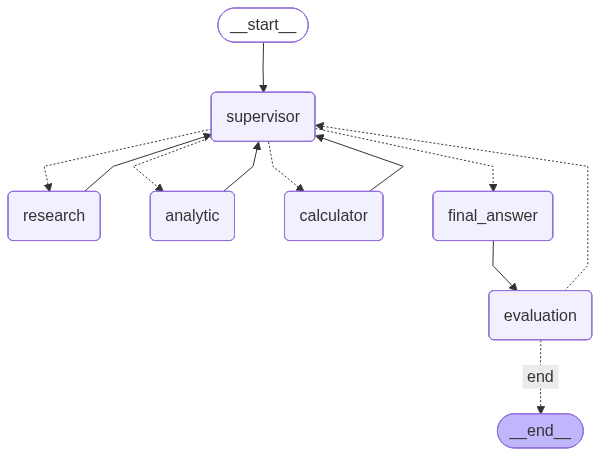

In [6]:
from IPython.display import Image, display

graph = maple_chat_graph()
try:
    
    display(
        Image(
            graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")